# Day 3: Exploratory Data Analysis (EDA)
### Mutual Fund Analytics Platform - Capstone Project
This notebook establishes the programmatic descriptive analytics layer by executing the required financial visualization targets.

In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

conn = sqlite3.connect('../bluestock_mf.db')
print('✅ Database connection established successfully.')

✅ Database connection established successfully.


### Task 1: NAV Trend Analysis (2022–2026)
Plotting daily historical NAV trends across tracked mutual fund schemes.

In [4]:
df_nav = pd.read_sql_query('SELECT * FROM fact_nav;', conn)
df_funds = pd.read_sql_query('SELECT amfi_code, fund_name FROM dim_fund;', conn)
df_nav_merged = df_nav.merge(df_funds, on='amfi_code')

sample_funds = df_nav_merged['fund_name'].unique()[:5]
df_plot = df_nav_merged[df_nav_merged['fund_name'].isin(sample_funds)]

fig = px.line(df_plot, x='date', y='nav', color='fund_name', 
              title='Historical NAV Trend Analysis (2022 - 2026)',
              labels={'date': 'Date', 'nav': 'Net Asset Value (INR)'})
fig.show()

### Task 2: AUM Growth Bar Chart by Fund House (2022–2025)

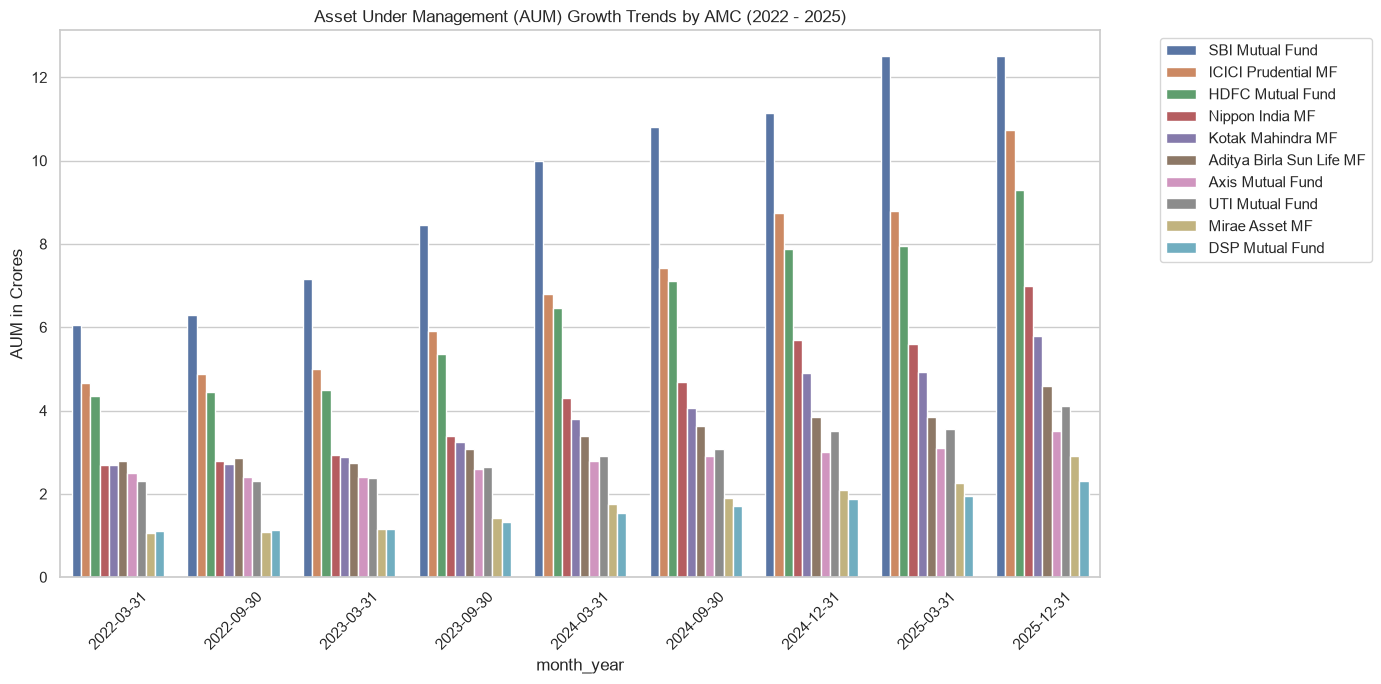

In [5]:
df_aum = pd.read_sql_query('SELECT * FROM fact_aum;', conn)
plt.figure(figsize=(14, 7))
sns.barplot(data=df_aum, x='month_year', y='aum_crore', hue='fund_house')
plt.title('Asset Under Management (AUM) Growth Trends by AMC (2022 - 2025)')
plt.xticks(rotation=45)
plt.ylabel('AUM in Crores')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Task 3: SIP Inflow Time-Series Trend Line

In [6]:
df_sip = pd.read_sql_query('SELECT * FROM fact_sip ORDER BY month_year ASC;', conn)
fig_sip = px.line(df_sip, x='month_year', y='sip_inflow_crore', 
                  title='Systemic Monthly SIP Inflow Trajectory Growth',
                  markers=True)
fig_sip.show()

### Task 4: Category-Wise Net Capital Inflow Heatmap

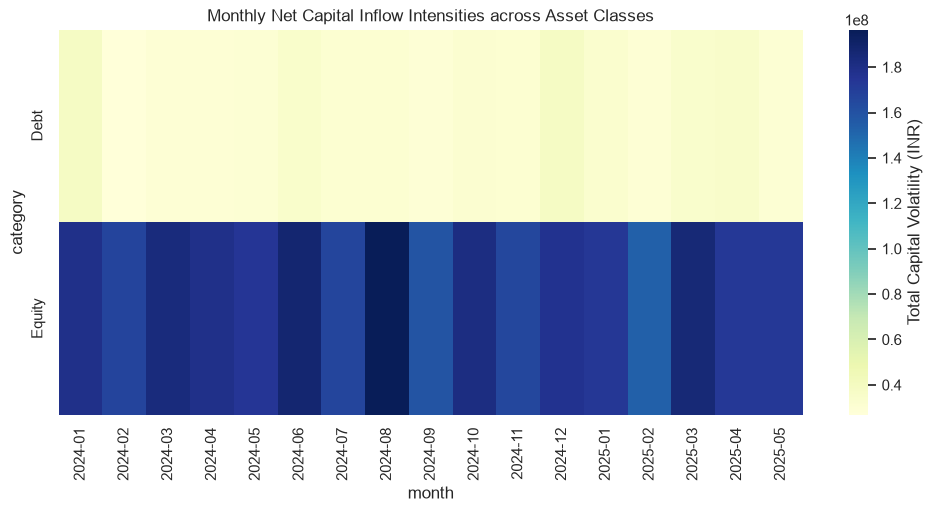

In [7]:
df_tx = pd.read_sql_query('SELECT t.transaction_date, f.category, t.amount_inr FROM fact_transactions t JOIN dim_fund f ON t.amfi_code = f.amfi_code;', conn)
df_tx['month'] = pd.to_datetime(df_tx['transaction_date']).dt.strftime('%Y-%m')
pivot_heatmap = df_tx.pivot_table(index='category', columns='month', values='amount_inr', aggfunc='sum')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_heatmap, cmap='YlGnBu', annot=False, fmt='.0f', cbar_kws={'label': 'Total Capital Volatility (INR)'})
plt.title('Monthly Net Capital Inflow Intensities across Asset Classes')
plt.show()

### Task 5: Investor Demographics (Age Segments & Ticket Sizes)

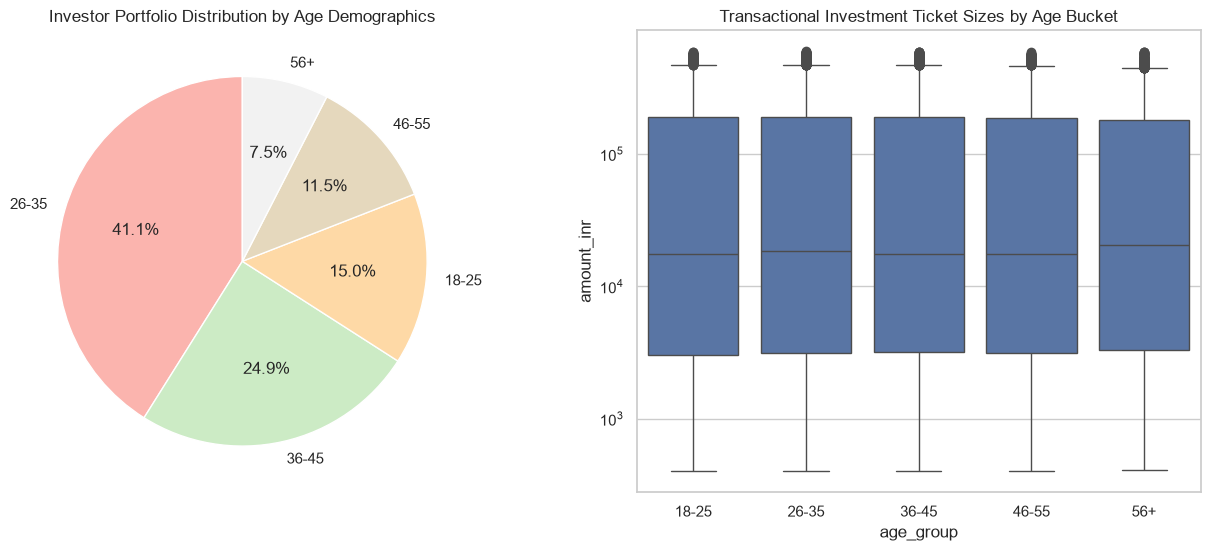

In [8]:
df_investor = pd.read_sql_query('SELECT age_group, amount_inr FROM fact_transactions;', conn)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_investor['age_group'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', cmap='Pastel1', startangle=90)
axes[0].set_title('Investor Portfolio Distribution by Age Demographics')
axes[0].set_ylabel('')

sns.boxplot(data=df_investor, x='age_group', y='amount_inr', ax=axes[1], order=sorted(df_investor['age_group'].unique()))
axes[1].set_title('Transactional Investment Ticket Sizes by Age Bucket')
axes[1].set_yscale('log')
plt.show()

### Task 6: Geographic Distribution Mapping

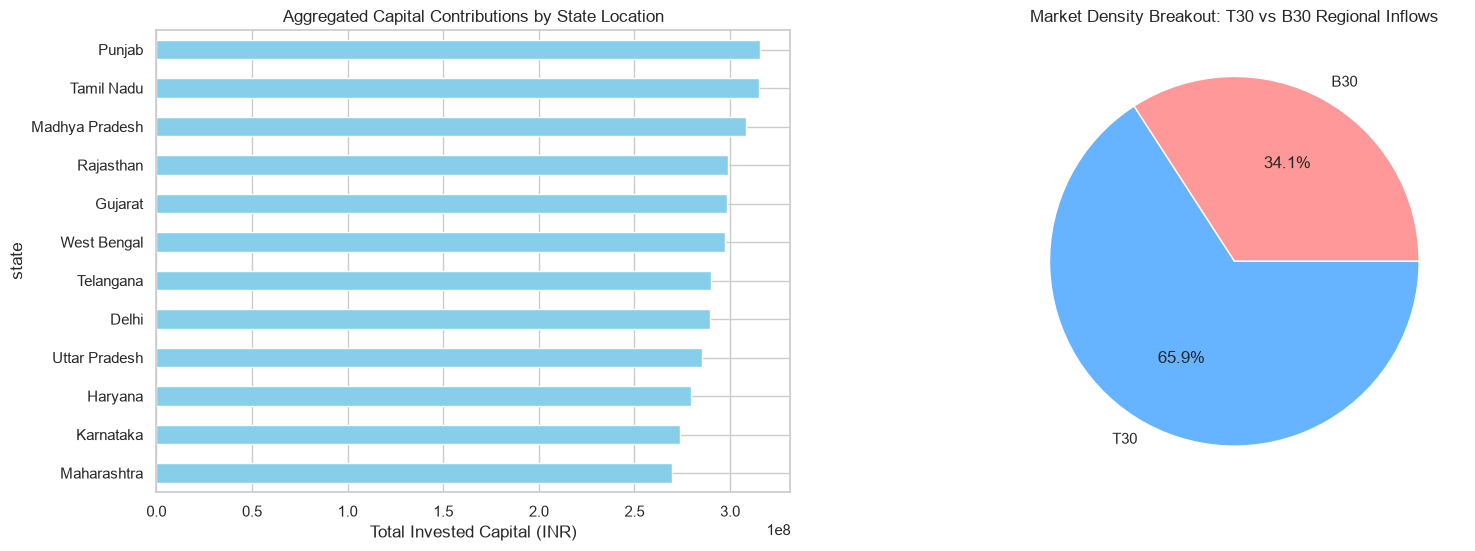

In [9]:
df_geo = pd.read_sql_query('SELECT state, city_tier, amount_inr FROM fact_transactions;', conn)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

df_geo.groupby('state')['amount_inr'].sum().sort_values().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Aggregated Capital Contributions by State Location')
axes[0].set_xlabel('Total Invested Capital (INR)')

df_geo.groupby('city_tier')['amount_inr'].sum().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[1].set_title('Market Density Breakout: T30 vs B30 Regional Inflows')
axes[1].set_ylabel('')
plt.show()

### Task 7: Folio Count Growth Metrics

In [10]:
df_folio = pd.read_sql_query('SELECT strftime("%Y-%m", transaction_date) as month, COUNT(DISTINCT investor_id) as active_folios FROM fact_transactions GROUP BY month ORDER BY month ASC;', conn)
fig_folio = px.bar(df_folio, x='month', y='active_folios', title='Active Client Folio Registration Counts Over Time', color='active_folios')
fig_folio.show()

### Task 8: Statistical Pairwise Asset Correlation Matrix

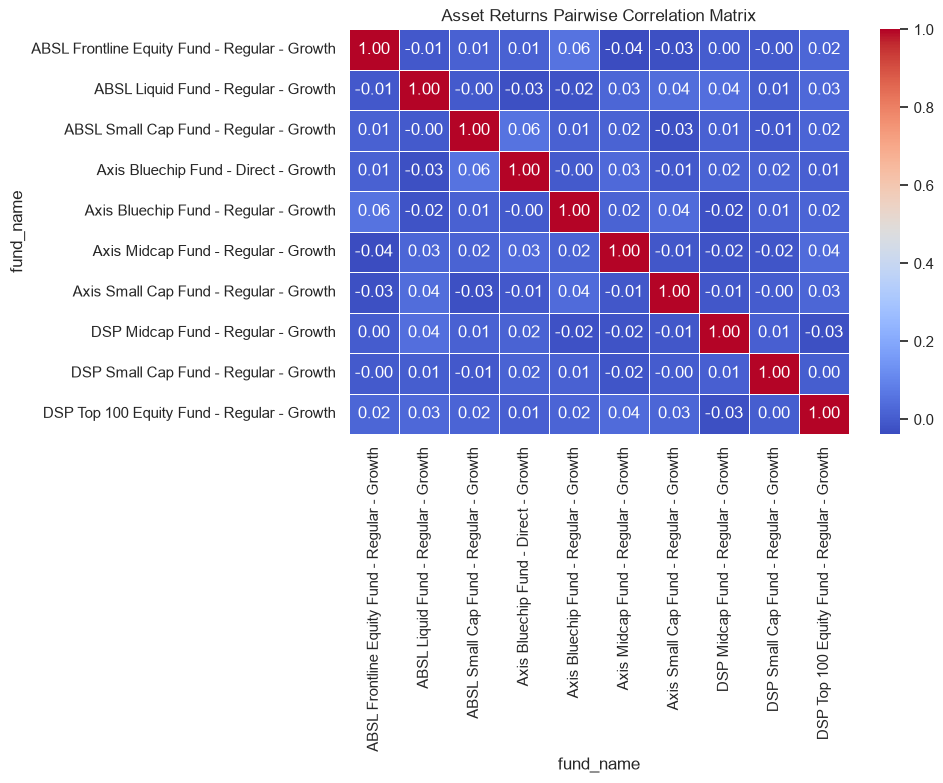

In [11]:
df_pivot_nav = df_nav_merged.pivot_table(index='date', columns='fund_name', values='nav').dropna()
corr_matrix = df_pivot_nav.iloc[:, :10].pct_change().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Asset Returns Pairwise Correlation Matrix')
plt.tight_layout()
plt.show()

### Task 9: Capital Allocations Share Distribution

In [13]:
# Query directly from dim_fund where 'category' is guaranteed to exist
df_funds_clean = pd.read_sql_query('SELECT category, amfi_code FROM dim_fund;', conn)

# Aggregate unique funds per category
df_cat_share = df_funds_clean.groupby('category')['amfi_code'].nunique().reset_index()

# Render the donut chart
fig_donut = px.pie(df_cat_share, values='amfi_code', names='category', hole=0.4, 
                   title='Tracked Asset Class Allocation Share Distribution')
fig_donut.show()